# Forecast Evaluation NHS Leavers

## Import Packages

In [76]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from forecast_tools.baseline import SNaive, Naive1
from forecast_tools.metrics import (
    winkler_score,
    absolute_coverage_difference,
    coverage,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
    symmetric_mean_absolute_percentage_error,
    mean_absolute_scaled_error
)
warnings.filterwarnings('ignore')
sns.set()

## Load data

In [77]:
file_path = r'S:\WP Personnel\A - Workforce\Data science student\Desys Corner\NHS_Leavers_Detail_New.csv'
leavers = pd.read_csv(file_path, parse_dates=['Termination Date'], dayfirst=True)

## Monthly Aggregation and leavers per day 

In [78]:
leavers['Month'] = leavers['Termination Date'].dt.to_period('M').dt.to_timestamp()
monthly = leavers.groupby('Month').size()
monthly.index.freq = 'MS'

# Calender adjustment
leavers_per_day = monthly / monthly.index.days_in_month

## Train test split 
Technique that splits dataset into training and testing set 
- training set is used to train the model
- testing set is used to evaluate its performance on new data
Allowing the model to generlise better and not mesmorise training data !

In [79]:
HORIZON = 12 
train = leavers_per_day.iloc[:-HORIZON]
test = leavers_per_day.iloc[-HORIZON:]
forecast_index = test.index

## Forecast Using Seasonal Naive

In [80]:
model = SNaive(period=12)
model.fit(train)
preds, intervals = model.predict(horizon=HORIZON, return_predict_int=True, alpha= [0.2, 0.1, 0.05])

## Forecast Errors

In [81]:
mae = mean_absolute_error(test, preds)
mse = mean_squared_error(test, preds)
rmse = root_mean_squared_error(test, preds)
mape = mean_absolute_percentage_error(test, preds)
smape = symmetric_mean_absolute_percentage_error(test, preds)
mase = mean_absolute_scaled_error(test, preds, y_train=train, period=12)

print("--- Point Forecast Errors ---")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"MAPE: {mape:.2f}")
print(f"sMAPE: {smape:.2f}")
print(f"MASE:  {mase:.2f}")

--- Point Forecast Errors ---
MAE: 2.83
RMSE: 4.49
MSE:  20.13
MAPE: 35.81
sMAPE: 27.26
MASE:  1.01


## Interpretation 
MAE:
- Meaning: Average absolute error 
- Interpretation: On average, the forecast is off ~2.8 leavers per day

RSME:
- Penalises larger errors more
- Suggests occasional larger deviations than MAE would imply.

MSE:
- Squared error
- Mainly useful for model training 

MAPE: 
- Relative error
- Forecast is off BY ~36% on average (% terms)

SMAPE:
- scaled MAPE
- Useful for skewed data

MASE:
- Scaled vs. naive model 
- The models accuracy is about as accurate as a seasonal naive forecast

Overall the model works but can be better ! 
Error is moderate 

## Converting prediction intervals into 2d arrays

In [82]:
# tuples to 2d arrays
interval_80 = np.column_stack(intervals[0]).T
interval_90 = np.column_stack(intervals[1]).T
interval_95 = np.column_stack(intervals[2]).T

## Evaluate Prediction Intervals 

In [83]:
print("Internal Evaluation")
for interval, alpha, label in zip([interval_80, interval_90, interval_95], [0.2, 0.1, 0.05], ["80%", "90%", "95%"]):
    cov = coverage(test.values, interval)
    ws = winkler_score(test.values, interval, alpha=alpha)
    acd = absolute_coverage_difference(test.values, interval, 1 - alpha)
    print(f"{label} | Coverage: {cov:.2f} | Winkler {ws:.2f} | ACD: {acd:.2f}")

Internal Evaluation
80% | Coverage: 0.83 | Winkler 19.63 | ACD: 0.63
90% | Coverage: 0.83 | Winkler 22.97 | ACD: 0.73
95% | Coverage: 0.92 | Winkler 21.30 | ACD: 0.87


## Interpretaion

80% - Coverage is better than expected (it should be 0.80), ACD = 0.63 - meaning its off by 3%
90% - Coverage is too low (it should be 0.90) 
95% - Best overal interval --> High coverage and appropriate width

The 95% is the most reliable range !

## Plotted Forecast 

In [88]:
def preds_as_series(data, preds):
    last_date = data.index.max()
    freq = data.index.freq or pd.infer_freq(data.index)
    offset = pd.tseries.frequencies.to_offset(freq)
    forecast_index = pd.date_range(start=last_date + offset, periods=len(preds), freq=freq)
    return pd.Series(preds, index=forecast_index)

def plot_prediction_interval(train, preds, interval_80, test=None):
    forecast = preds_as_series(train, preds)
    interval_idx = forecast.index

    ax = train.plot(figsize=(12, 4), label='Train', color='black')
    forecast.plot(ax=ax, label='Forecast', color='pink')

    ax.fill_between(interval_idx, interval_80[:, 0], interval_80[:, 1],
                    color='blue', alpha=0.3, label='80% PI')
    if test is not None:
        test.plot(ax=ax, label='Test', color='red')

    ax.legend()
    plt.title('NHS Leavers Forecast with 80% Prediction Interval')
    plt.ylabel('Leavers per Day')
    plt.xlabel('Month')
    plt.tight_layout()
    plt.show()

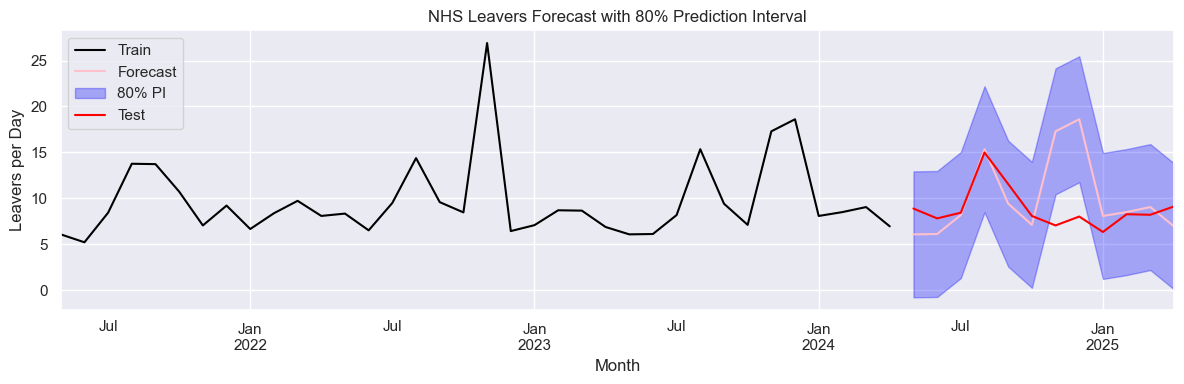

In [89]:
plot_prediction_interval(train, preds, interval_80, test)

## Next Steps 

- Overall the baseline forecast (seasonal naive mode) has been benchmarked
- The 95% prediction interval should be used !

To reinforce accuracy ARIMA (autoagressive integrated moving average)  
- Statistical model used for time series analysis and forecasting
- Combines autoregression (AR)
- Differencing for stationarity (I)
- Moving averages (MA)
and predicts future values conidering past values and past forecast errors



Add feautres
- Use known future variables such as potential recuritment campaigns, policy changes or holiday effects

Check segment level forecast
- Breakdown by department or staff group may reveal different patterns
- Using Nixtlaverse hieracrchal forecast

Using rolling forecast 
- Re train the model monthly and forecast forward
- improves stability over time
